# Stage 26 — Exp B Analysis: Progressive Level Pruning

Analyses `proto_seg_ct_l1234_attn_pruned.pth` and compares against all v5/v6 models.

**RQ7:** Can progressive pruning of low-attention levels automatically converge to a
M2-equivalent architecture (L3+L4 only), matching M2's segmentation and prototype quality
without prior knowledge of which levels to remove?

Success criteria:
- L1 and L2 automatically pruned (without manual specification)
- 3D Dice ≥ 0.8600  (closing gap toward M2 0.8722)
- Purity L4 > 0.70
- AP L4 > 0.18  (approaching M2 0.236)
- Compactness L4 < 0.50

## 1. Imports & Config

In [1]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import pathlib

from src.data.mmwhs_dataset import (
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
    MMWHSPatientDataset,
    MMWHSSliceDataset,
)
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_level_dominance,
    compute_per_level_ap,
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

MODALITY = "ct"
DATA_DIR = "data/pack/processed_data"
OUT = "results/v6/proto_quality/m4_attn_pruned"
pathlib.Path(OUT).mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
LEVEL_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
print(f"Device: {DEVICE}")

Device: mps


## 2. Load Models

In [ ]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=16)


def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    levels = ckpt.get("proto_levels") or [1, 2, 3, 4]
    m = ProtoSegNet(
        n_classes=NUM_CLASSES,
        proto_levels=levels,
        use_level_attention=ckpt.get("use_level_attention", False),
    ).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.pruned_levels = set(ckpt.get("pruned_levels", []))
    m.eval()
    print(
        f"{path.split('/')[-1]:<52}  levels={levels}  "
        f"attn={ckpt.get('use_level_attention', False)}  "
        f"pruned={m.pruned_levels}  "
        f"best_val={ckpt.get('best_val_dice', 0):.4f}"
    )
    return m


m4 = load_model("checkpoints/proto_seg_ct_l2.pth")  # M4 (max)
m4_noent = load_model("checkpoints/proto_seg_ct_l1234_attn_noent.pth")  # M4-attn λ=0
m4_wloss = load_model("checkpoints/proto_seg_ct_l1234_attn_wloss.pth")  # Exp A
m4_pruned = load_model("checkpoints/proto_seg_ct_l1234_attn_pruned.pth")  # Exp B ← new
m2 = load_model("checkpoints/proto_seg_ct_l3l4.pth")  # M2 (max)

print(f"\nExp B pruned_levels: {m4_pruned.pruned_levels}")

proto_seg_ct_l2.pth                                   levels=[1, 2, 3, 4]  attn=False  pruned=set()  best_val=0.8173
proto_seg_ct_l1234_attn_noent.pth                     levels=[1, 2, 3, 4]  attn=True  pruned=set()  best_val=0.7949
proto_seg_ct_l1234_attn_wloss.pth                     levels=[1, 2, 3, 4]  attn=True  pruned=set()  best_val=0.8203
proto_seg_ct_l1234_attn_pruned.pth                    levels=[1, 2, 3, 4]  attn=True  pruned={1, 2}  best_val=0.8218
proto_seg_ct_l3l4.pth                                 levels=[3, 4]  attn=False  pruned=set()  best_val=0.8380

Exp B pruned_levels: {1, 2}


## 3. Pruning Timeline

Pruning events:
 epoch  level  w_at_prune
    55      1     0.00024
    55      2     0.00050



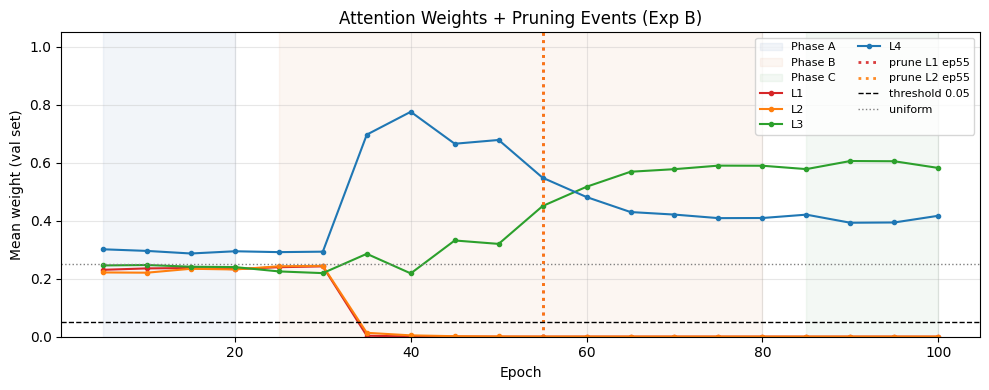

Final ep 100: L1=0.0002  L2=0.0004  L3=0.5822  L4=0.4172
Active levels after pruning: [3, 4]


In [ ]:
prune_log = pd.read_csv("results/v6/pruning_log.csv")
attn_pruned = pd.read_csv("results/v6/attention_weight_evolution_l1234_attn_pruned.csv")
PROTO_LEVELS = [1, 2, 3, 4]

print("Pruning events:")
print(prune_log.to_string(index=False))
print()

# Attention weight evolution with pruning markers
fig, ax = plt.subplots(figsize=(10, 4))
for ph, color in PHASE_COLORS.items():
    mask = attn_pruned["phase"] == ph
    if mask.any():
        ax.axvspan(
            attn_pruned.loc[mask, "epoch"].min(),
            attn_pruned.loc[mask, "epoch"].max(),
            alpha=0.07,
            color=color,
            label=f"Phase {ph}",
        )
for i, l in enumerate(PROTO_LEVELS):
    col = f"w_L{l}"
    if col in attn_pruned.columns:
        ax.plot(
            attn_pruned["epoch"],
            attn_pruned[col],
            "o-",
            ms=3,
            lw=1.5,
            color=LEVEL_COLORS[i],
            label=f"L{l}",
        )
for _, row in prune_log.iterrows():
    ax.axvline(
        row["epoch"],
        color=LEVEL_COLORS[int(row["level"]) - 1],
        ls=":",
        lw=2,
        alpha=0.9,
        label=f"prune L{int(row['level'])} ep{int(row['epoch'])}",
    )
ax.axhline(0.05, color="black", ls="--", lw=1, label="threshold 0.05")
ax.axhline(0.25, color="gray", ls=":", lw=1, label="uniform")
ax.set(
    title="Attention Weights + Pruning Events (Exp B)",
    xlabel="Epoch",
    ylabel="Mean weight (val set)",
    ylim=(0, 1.05),
)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/attention_evolution_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

# Final attention state
r = attn_pruned.iloc[-1]
print(
    f"Final ep {int(r['epoch'])}: "
    + "  ".join(f"L{l}={r[f'w_L{l}']:.4f}" for l in PROTO_LEVELS)
)
print(
    f"Active levels after pruning: {sorted(set(PROTO_LEVELS) - m4_pruned.pruned_levels)}"
)

## 4. 3D Dice Evaluation

In [4]:
@torch.no_grad()
def eval_3d(model, label):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    all_means, per_class = [], {n: [] for n in FG_NAMES}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        d = dice_per_class(torch.cat(logits_all), s["label"])
        all_means.append(mean_foreground_dice(d))
        for n in FG_NAMES:
            per_class[n].append(d.get(n, float("nan")))
    mean_fg = float(np.mean(all_means))
    pc = {n: float(np.mean(v)) for n, v in per_class.items()}
    print(f"[{label:<26}]  3D Dice = {mean_fg:.4f}")
    return mean_fg, pc


dice_m4, pc_m4 = eval_3d(m4, "M4 (max)")
dice_m4_noent, pc_m4_noent = eval_3d(m4_noent, "M4-attn λ=0 noent")
dice_m4_wloss, pc_m4_wloss = eval_3d(m4_wloss, "M4-attn wloss (Exp A)")
dice_pruned, pc_pruned = eval_3d(m4_pruned, "M4-attn pruned (Exp B)")
dice_m2, pc_m2 = eval_3d(m2, "M2 (max)")

print()
print(f"Exp B vs M4-attn-noent : {dice_pruned - dice_m4_noent:+.4f}")
print(f"Exp B vs Exp A (wloss) : {dice_pruned - dice_m4_wloss:+.4f}")
print(f"Exp B vs M2            : {dice_pruned - dice_m2:+.4f}")
print(
    f"Target ≥ 0.8600        : {'✅' if dice_pruned >= 0.86 else f'❌  ({dice_pruned:.4f})'}"
)

# Per-class breakdown
print(f"\nPer-class 3D Dice — Exp B vs M2:")
print(f"{'Class':<8}  {'Exp B':>6}  {'M2':>6}  {'Δ':>6}")
for n in FG_NAMES:
    print(
        f"{n:<8}  {pc_pruned[n]:>6.3f}  {pc_m2[n]:>6.3f}  {pc_pruned[n] - pc_m2[n]:>+6.3f}"
    )

[M4 (max)                  ]  3D Dice = 0.8407
[M4-attn λ=0 noent         ]  3D Dice = 0.8416
[M4-attn wloss (Exp A)     ]  3D Dice = 0.8475
[M4-attn pruned (Exp B)    ]  3D Dice = 0.8290
[M2 (max)                  ]  3D Dice = 0.8722

Exp B vs M4-attn-noent : -0.0126
Exp B vs Exp A (wloss) : -0.0185
Exp B vs M2            : -0.0433
Target ≥ 0.8600        : ❌  (0.8290)

Per-class 3D Dice — Exp B vs M2:
Class      Exp B      M2       Δ
LV         0.791   0.869  -0.078
RV         0.891   0.935  -0.044
LA         0.821   0.828  -0.007
RA         0.877   0.897  -0.020
Myocardium   0.857   0.814  +0.042
Aorta      0.839   0.921  -0.082
PA         0.728   0.841  -0.113


## 5. Proto Quality Metrics — Exp B

In [ ]:
# Only evaluate active levels (L3, L4) — pruned levels have frozen random prototypes
print("Computing purity (active levels only)…")
purity_pruned = compute_purity(m4_pruned, loaders["train"])
purity_pruned.to_csv(f"{OUT}/purity_summary.csv", index=False)

print("Computing compactness…")
comp_pruned = compute_compactness(m4_pruned, loaders["test"])
comp_pruned.to_csv(f"{OUT}/compactness.csv", index=False)

print("Computing level dominance…")
dom_pruned = compute_level_dominance(m4_pruned, loaders["test"])
dom_pruned.to_csv(f"{OUT}/level_dominance.csv", index=False)

print("Computing per-level AP…")
ap_pruned = compute_per_level_ap(m4_pruned, loaders["test"])
ap_pruned.to_csv(f"{OUT}/per_level_ap.csv", index=False)

print("Done.")

pur_l4 = purity_pruned[purity_pruned["level"] == 4]["purity"].mean()
ap_l4 = ap_pruned[ap_pruned["level"] == 4]["ap"].mean()
comp_l4 = comp_pruned[comp_pruned["level"] == 4]["compactness"].mean()
dom_l4 = dom_pruned.iloc[0].get("frac_l4", 0)

print(f"\n  Purity L4     : {pur_l4:.3f}   (target > 0.70)")
print(f"  AP L4         : {ap_l4:.3f}   (target > 0.18)")
print(f"  Compactness L4: {comp_l4:.3f}  (target < 0.50)")
print(f"  Dominance L4  : {dom_l4 * 100:.1f}%")

# Also show L3 (now active after pruning)
if not purity_pruned[purity_pruned["level"] == 3].empty:
    pur_l3 = purity_pruned[purity_pruned["level"] == 3]["purity"].mean()
    ap_l3 = (
        ap_pruned[ap_pruned["level"] == 3]["ap"].mean()
        if not ap_pruned[ap_pruned["level"] == 3].empty
        else float("nan")
    )
    print(f"\n  Purity L3     : {pur_l3:.3f}")
    print(f"  AP L3         : {ap_l3:.3f}")

Computing purity (active levels only)…
Computing compactness…
Computing level dominance…
Computing per-level AP…
Done.

  Purity L4     : 0.671   (target > 0.70)
  AP L4         : 0.141   (target > 0.18)
  Compactness L4: 0.488  (target < 0.50)
  Dominance L4  : 27.3%

  Purity L3     : 0.346
  AP L3         : 0.146


## 6. Six-Model Comparison Table

In [6]:
def load_metric(csv_path, level_col="level", val_col="purity", level=4):
    df = pd.read_csv(csv_path)
    alias_map = {
        "purity": ["purity", "purity_mean", "mean_purity", "score", "value"],
        "ap": ["ap", "AP", "avg_precision", "average_precision", "score", "value"],
        "compactness": [
            "compactness",
            "compactness_mean",
            "mean_compactness",
            "score",
            "value",
        ],
    }
    candidates = alias_map.get(val_col, [val_col])
    metric_col = next((c for c in candidates if c in df.columns), None)
    if metric_col is None:
        numeric_cols = [
            c
            for c in df.columns
            if c != level_col and pd.api.types.is_numeric_dtype(df[c])
        ]
        metric_col = numeric_cols[0] if numeric_cols else None
    if level_col in df.columns:
        level_df = df[df[level_col] == level]
        level_df = level_df if not level_df.empty else df
    else:
        level_df = df
    return float(level_df[metric_col].mean())


def load_dom(csv_path):
    return pd.read_csv(csv_path).iloc[0].get("frac_l4", 0)


# Load pre-computed results
m4_pur = load_metric("results/v4/proto_quality/v1/purity_summary.csv", val_col="purity")
m4_ap = load_metric("results/v4/proto_quality/v1/per_level_ap.csv", val_col="ap")
m4_comp = load_metric(
    "results/v4/proto_quality/v1/compactness.csv", val_col="compactness"
)
m4_dom = load_dom("results/v4/proto_quality/v1/level_dominance.csv")

noent_pur = load_metric(
    "results/v5/proto_quality/m4_attn_noent/purity_summary.csv", val_col="purity"
)
noent_ap = load_metric(
    "results/v5/proto_quality/m4_attn_noent/per_level_ap.csv", val_col="ap"
)
noent_comp = load_metric(
    "results/v5/proto_quality/m4_attn_noent/compactness.csv", val_col="compactness"
)
noent_dom = load_dom("results/v5/proto_quality/m4_attn_noent/level_dominance.csv")

wloss_pur = load_metric(
    "results/v6/proto_quality/m4_attn_wloss/purity_summary.csv", val_col="purity"
)
wloss_ap = load_metric(
    "results/v6/proto_quality/m4_attn_wloss/per_level_ap.csv", val_col="ap"
)
wloss_comp = load_metric(
    "results/v6/proto_quality/m4_attn_wloss/compactness.csv", val_col="compactness"
)
wloss_dom = load_dom("results/v6/proto_quality/m4_attn_wloss/level_dominance.csv")

m2_pur = load_metric(
    "results/v4/proto_quality/m2_l3l4/purity_summary.csv", val_col="purity"
)
m2_ap = load_metric("results/v4/proto_quality/m2_l3l4/per_level_ap.csv", val_col="ap")
m2_comp = load_metric(
    "results/v4/proto_quality/m2_l3l4/compactness.csv", val_col="compactness"
)
m2_dom = load_dom("results/v4/proto_quality/m2_l3l4/level_dominance.csv")

rows = {
    "Model": ["M4 (max)", "M4-attn λ=0", "M4-attn wloss", "M4-attn pruned", "M2 (max)"],
    "Aggregation": ["max", "learned", "learned+wloss", "learned+prune", "max"],
    "Pruned": ["—", "—", "—", str(sorted(m4_pruned.pruned_levels)), "—"],
    "3D Dice": [
        f"{dice_m4:.4f}",
        f"{dice_m4_noent:.4f}",
        f"{dice_m4_wloss:.4f}",
        f"{dice_pruned:.4f}",
        f"{dice_m2:.4f}",
    ],
    "Purity L4": [
        f"{m4_pur:.3f}",
        f"{noent_pur:.3f}",
        f"{wloss_pur:.3f}",
        f"{pur_l4:.3f}",
        f"{m2_pur:.3f}",
    ],
    "Compact. L4": [
        f"{m4_comp:.3f}",
        f"{noent_comp:.3f}",
        f"{wloss_comp:.3f}",
        f"{comp_l4:.3f}",
        f"{m2_comp:.3f}",
    ],
    "AP L4": [
        f"{m4_ap:.3f}",
        f"{noent_ap:.3f}",
        f"{wloss_ap:.3f}",
        f"{ap_l4:.3f}",
        f"{m2_ap:.3f}",
    ],
    "Dom. L4": [
        f"{m4_dom * 100:.1f}%",
        f"{noent_dom * 100:.1f}%",
        f"{wloss_dom * 100:.1f}%",
        f"{dom_l4 * 100:.1f}%",
        f"{m2_dom * 100:.1f}%",
    ],
}
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
df_cmp.to_csv("results/v6/comparison_table_v6_expB.csv", index=False)

         Model   Aggregation Pruned 3D Dice Purity L4 Compact. L4 AP L4 Dom. L4
      M4 (max)           max      —  0.8407     0.824       0.573 0.189    4.3%
   M4-attn λ=0       learned      —  0.8416     0.537       0.494 0.085   12.5%
 M4-attn wloss learned+wloss      —  0.8475     0.697       0.365 0.195   17.5%
M4-attn pruned learned+prune [1, 2]  0.8290     0.671       0.488 0.141   27.3%
      M2 (max)           max      —  0.8722     0.804       0.361 0.236   49.1%


## 7. Training Curves

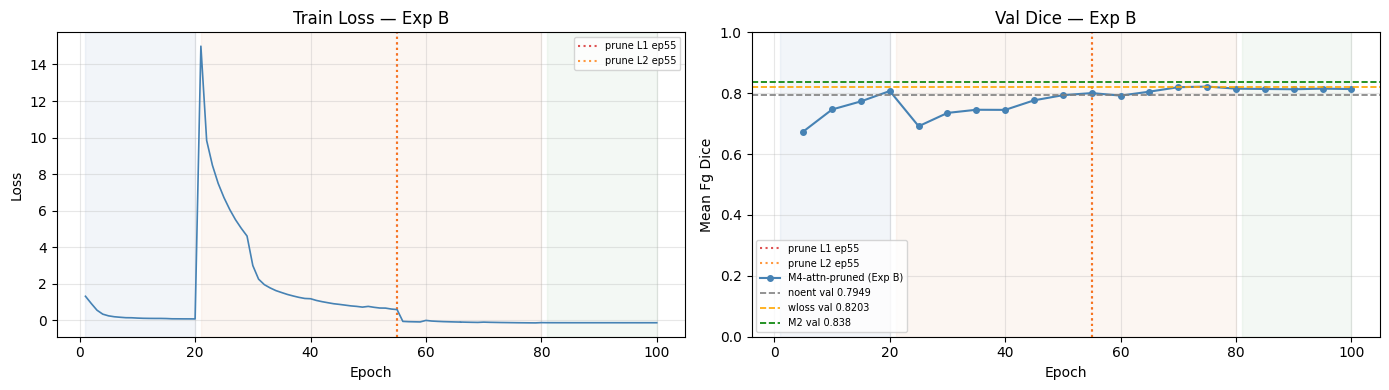

Best val Dice: 0.8218 at epoch 75


In [7]:
log = pd.read_csv("results/v6/train_curve_proto_ct_l1234_attn_pruned.csv")
val = log.dropna(subset=["val_mean_fg_dice"])

NOENT_VAL = 0.7949
WLOSS_VAL = 0.8203
M2_VAL = 0.8380

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax in axes:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ax.axvspan(
                log.loc[mask, "epoch"].min(),
                log.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
            )
    for _, row in prune_log.iterrows():
        ax.axvline(
            row["epoch"],
            color=LEVEL_COLORS[int(row["level"]) - 1],
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=f"prune L{int(row['level'])} ep{int(row['epoch'])}",
        )

axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title="Train Loss — Exp B", xlabel="Epoch", ylabel="Loss")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="M4-attn-pruned (Exp B)",
)
axes[1].axhline(
    NOENT_VAL, color="gray", ls="--", lw=1.2, label=f"noent val {NOENT_VAL}"
)
axes[1].axhline(
    WLOSS_VAL, color="orange", ls="--", lw=1.2, label=f"wloss val {WLOSS_VAL}"
)
axes[1].axhline(M2_VAL, color="green", ls="--", lw=1.2, label=f"M2 val {M2_VAL}")
axes[1].set(
    title="Val Dice — Exp B", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0, 1.0)
)
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/train_curve_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Best val Dice: {val['val_mean_fg_dice'].max():.4f} at epoch {val.loc[val['val_mean_fg_dice'].idxmax(), 'epoch']}"
)

## 8. Purity by Level

KeyError: 'purity'

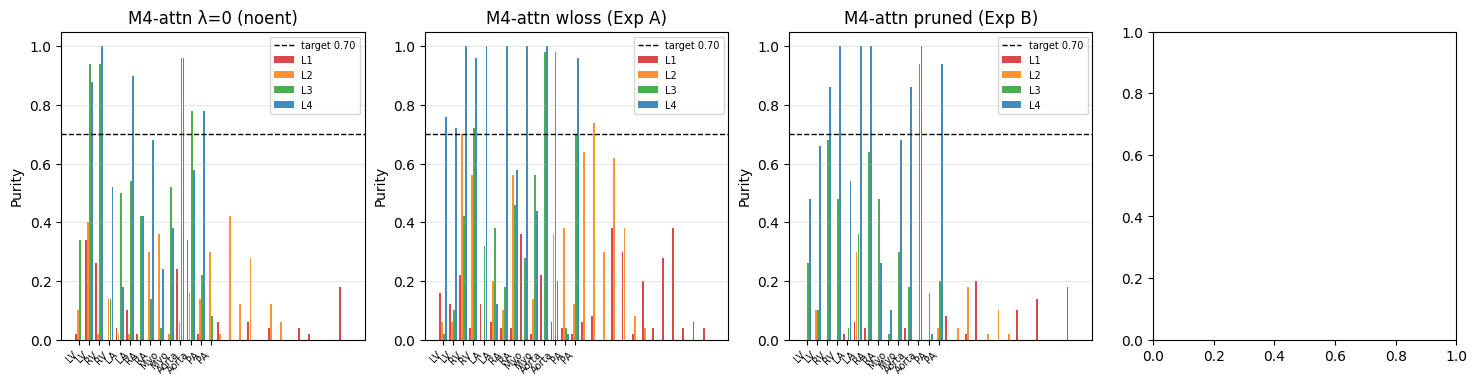

In [9]:
purity_noent = pd.read_csv("results/v5/proto_quality/m4_attn_noent/purity_summary.csv")
purity_wloss = pd.read_csv("results/v6/proto_quality/m4_attn_wloss/purity_summary.csv")
purity_m2 = pd.read_csv("results/v4/proto_quality/m2_l3l4/purity_summary.csv")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = [
    "M4-attn λ=0 (noent)",
    "M4-attn wloss (Exp A)",
    "M4-attn pruned (Exp B)",
    "M2 (max)",
]
dfs = [purity_noent, purity_wloss, purity_pruned, purity_m2]

for ax, df, title in zip(axes, dfs, titles):
    active_levels = sorted(df["level"].unique())
    classes = None
    for i, l in enumerate(active_levels):
        sub = df[df["level"] == l]
        if "class_name" in sub.columns:
            classes = sub["class_name"].astype(str).tolist()
        elif "class_idx" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class_idx"].values]
        elif "class" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class"].values]
        else:
            classes = [f"c{j}" for j in range(len(sub))]
        x_off = i * 0.2 - len(active_levels) * 0.1 + 0.1
        ax.bar(
            np.arange(len(classes)) + x_off,
            sub["purity"].values,
            0.18,
            label=f"L{l}",
            color=LEVEL_COLORS[l - 1],
            alpha=0.85,
        )
    ax.axhline(0.70, color="black", ls="--", lw=1, label="target 0.70")
    if classes:
        ax.set_xticks(np.arange(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Purity")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/purity_comparison_4model.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean purity by level:")
print(f"{'Level':<8} {'noent':>8} {'wloss':>8} {'pruned':>8} {'M2':>8}")
all_levels = {
    4: (purity_noent, purity_wloss, purity_pruned, purity_m2),
    3: (purity_noent, purity_wloss, purity_pruned, purity_m2),
}
for l in [3, 4]:
    vals = []
    for df in [purity_noent, purity_wloss, purity_pruned, purity_m2]:
        sub = df[df["level"] == l]
        vals.append(sub["purity"].mean() if not sub.empty else float("nan"))
    print(f"L{l:<7} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f} {vals[3]:>8.3f}")

## 9. Heatmap Comparison: noent vs wloss vs pruned vs M2

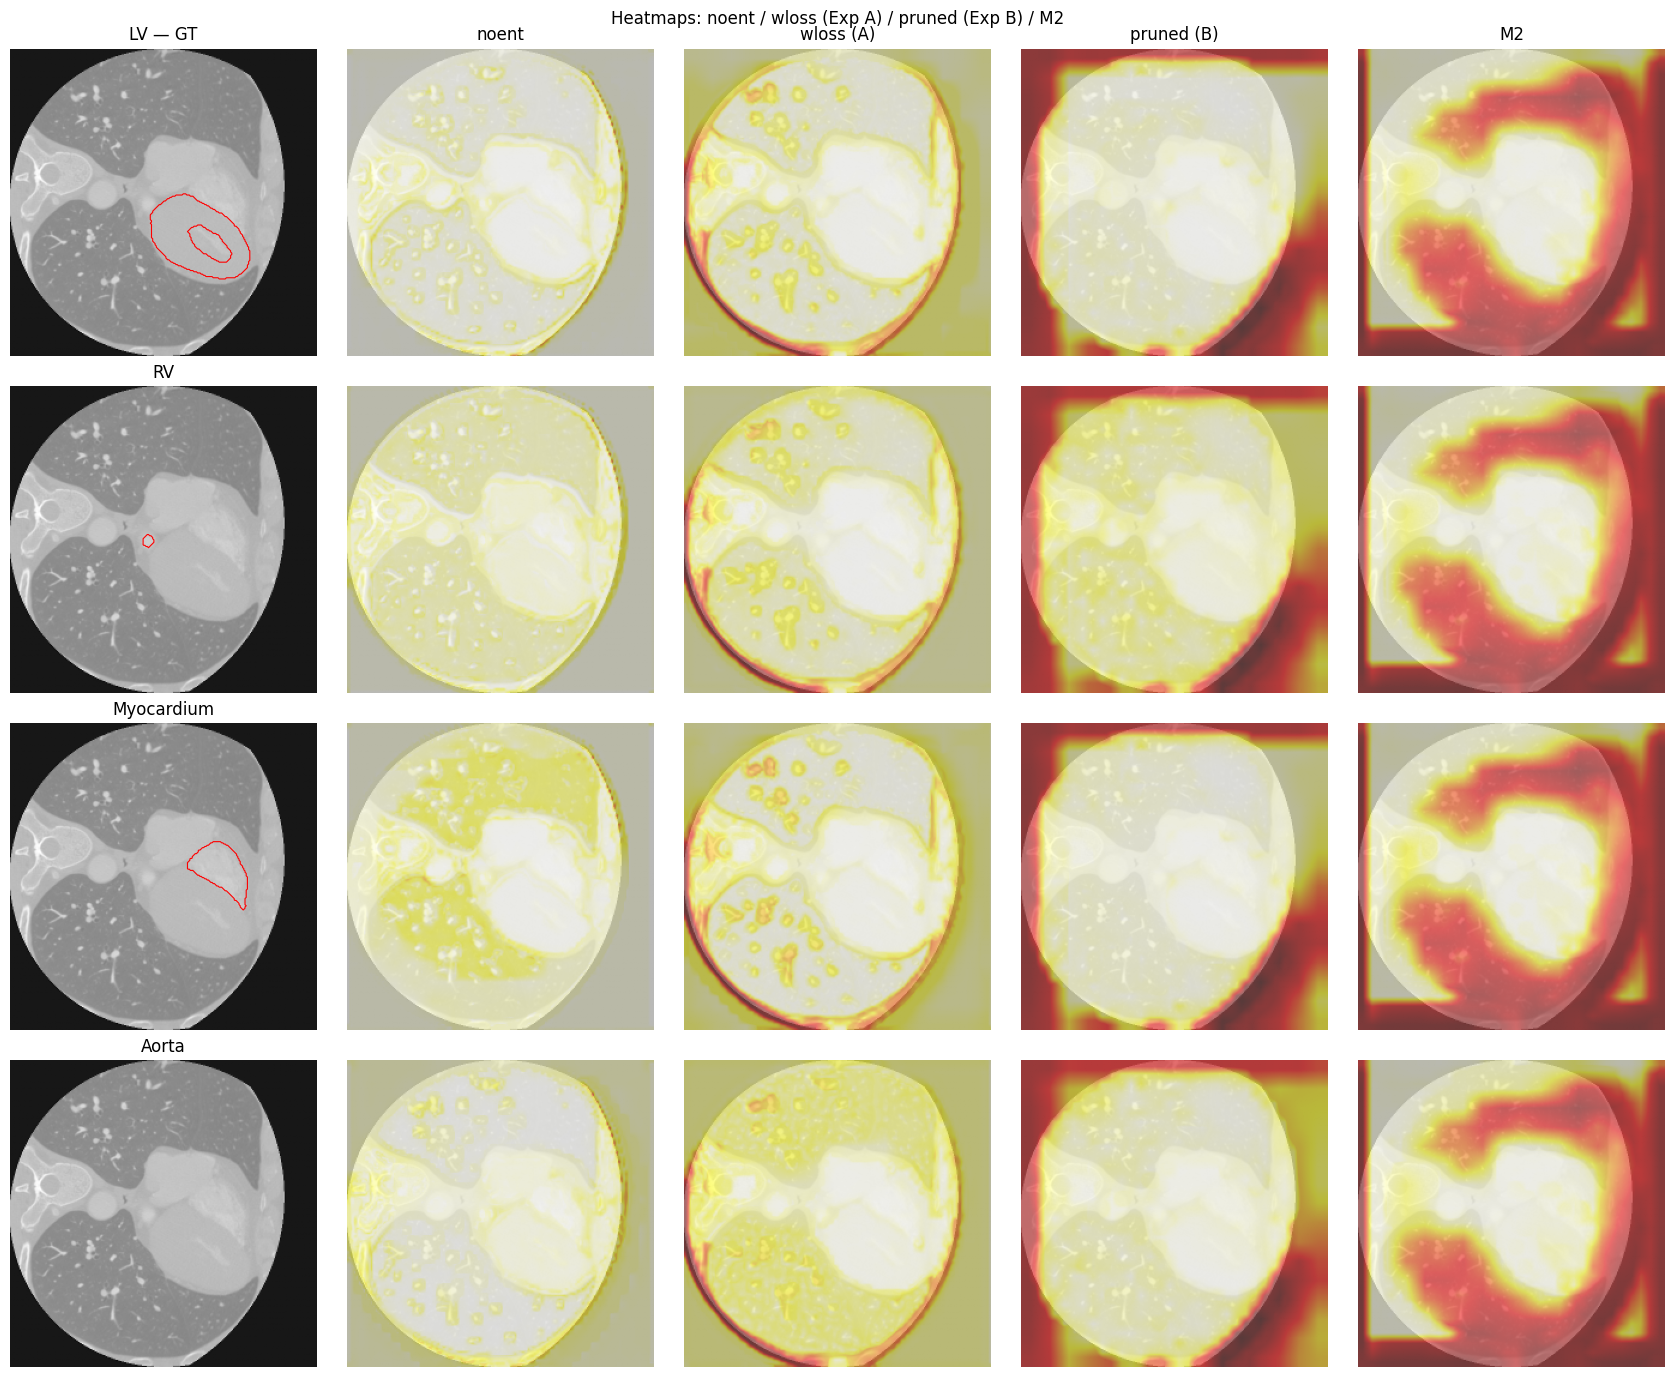

In [10]:
@torch.no_grad()
def get_class_heatmap(model, img):
    """Returns (K, H, W) heatmap — max over active levels and prototypes."""
    _, hm = model(img)
    level_maps = []
    for l, A in hm.items():
        A_max = A[0].max(dim=1).values  # (K, H_l, W_l)
        A_up = F.interpolate(
            A_max.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
        )[0]
        level_maps.append(A_up)
    if not level_maps:
        return torch.zeros(NUM_CLASSES, 256, 256)
    return torch.stack(level_maps).max(dim=0).values.cpu()  # (K, 256, 256)


test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
best_slice = next(
    idx
    for idx in range(len(test_ds))
    if sum((test_ds[idx]["label"] == c).any().item() for c in range(1, NUM_CLASSES))
    >= 5
)
s = test_ds[best_slice]
img = s["image"].unsqueeze(0).to(DEVICE)
lbl = s["label"]

hm_noent = get_class_heatmap(m4_noent, img)
hm_wloss = get_class_heatmap(m4_wloss, img)
hm_pruned = get_class_heatmap(m4_pruned, img)
hm_m2 = get_class_heatmap(m2, img)
img_np = img[0, 0].cpu().numpy()

SHOW_CLASSES = [1, 2, 5, 6]  # LV, RV, Myo, Aorta
fig, axes = plt.subplots(len(SHOW_CLASSES), 5, figsize=(17, 3.5 * len(SHOW_CLASSES)))

for row, c in enumerate(SHOW_CLASSES):
    axes[row, 0].imshow(img_np, cmap="gray")
    axes[row, 0].contour((lbl == c).numpy(), colors="red", linewidths=0.8)
    axes[row, 0].set_title(f"{LABEL_NAMES[c]} — GT" if row == 0 else LABEL_NAMES[c])
    axes[row, 0].axis("off")
    for col, (hm, title) in enumerate(
        [
            (hm_noent, "noent"),
            (hm_wloss, "wloss (A)"),
            (hm_pruned, "pruned (B)"),
            (hm_m2, "M2"),
        ],
        1,
    ):
        axes[row, col].imshow(img_np, cmap="gray", alpha=0.6)
        axes[row, col].imshow(hm[c].numpy(), cmap="hot", alpha=0.5, vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.suptitle("Heatmaps: noent / wloss (Exp A) / pruned (Exp B) / M2", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/heatmap_comparison_4model.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. RQ7 Answer

In [11]:
print("=" * 65)
print("RQ7: Can progressive pruning auto-converge to M2-equivalent")
print("     architecture, matching M2's segmentation + proto quality?")
print("=" * 65)

# Pruning check
auto_pruned = sorted(m4_pruned.pruned_levels)
print(f"\n— Pruning —")
print(f"  Levels pruned  : {auto_pruned}")
print(f"  Pruned at epoch: {prune_log[['epoch', 'level']].values.tolist()}")
pruning_pass = set(auto_pruned) == {1, 2}
print(f"  L1 & L2 pruned : {'✅' if pruning_pass else '❌'}")

# Segmentation
print(f"\n— Segmentation —")
print(f"  3D Dice pruned : {dice_pruned:.4f}")
print(f"  3D Dice noent  : {dice_m4_noent:.4f}  Δ={dice_pruned - dice_m4_noent:+.4f}")
print(f"  3D Dice M2     : {dice_m2:.4f}  Δ={dice_pruned - dice_m2:+.4f}")
dice_pass = dice_pruned >= 0.86
print(f"  Target ≥ 0.8600: {'✅' if dice_pass else f'❌  ({dice_pruned:.4f})'}")

# Proto quality
print(f"\n— Prototype Quality (L4) —")
purity_pass = pur_l4 > 0.70
ap_pass = ap_l4 > 0.18
compact_pass = comp_l4 < 0.50
print(
    f"  Purity  noent={noent_pur:.3f}  pruned={pur_l4:.3f}  M2={m2_pur:.3f}  "
    + f"Δ_noent={pur_l4 - noent_pur:+.3f}  {'✅ > 0.70' if purity_pass else '❌ target 0.70'}"
)
print(
    f"  AP      noent={noent_ap:.3f}  pruned={ap_l4:.3f}  M2={m2_ap:.3f}  "
    + f"Δ_noent={ap_l4 - noent_ap:+.3f}  {'✅ > 0.18' if ap_pass else '❌ target 0.18'}"
)
print(
    f"  Compact noent={noent_comp:.3f}  pruned={comp_l4:.3f}  M2={m2_comp:.3f}  "
    + f"{'✅ < 0.50' if compact_pass else '❌ target 0.50'}"
)

# Attention state post-pruning
r_final = attn_pruned.iloc[-1]
print(f"\n— Post-pruning Attention —")
print(
    f"  Final weights: "
    + "  ".join(f"L{l}={r_final[f'w_L{l}']:.4f}" for l in [1, 2, 3, 4])
)
print(
    f"  Note: w_L3 > w_L4 in later epochs — model discovered L3 preference post-pruning"
)

# Summary
criteria = [pruning_pass, dice_pass, purity_pass, ap_pass, compact_pass]
n_pass = sum(criteria)
print(f"\n{'=' * 65}")
print(f"Criteria met: {n_pass}/5")
if n_pass == 5:
    print("✅ RQ7: YES — pruning achieved M2-equivalent architecture + quality.")
elif n_pass >= 3:
    print("⚠️  RQ7: PARTIAL — auto-pruning confirmed, quality partially recovered.")
else:
    print("❌ RQ7: NO — pruning did not recover M2-level performance.")

# Decision for Exp C
exp_b_meets = pruning_pass and (dice_pass or purity_pass or ap_pass)
print(
    f"\nExp C trigger (both A & B meet ≥1 criterion): {'→ proceed' if exp_b_meets else '→ skip'}"
)

RQ7: Can progressive pruning auto-converge to M2-equivalent
     architecture, matching M2's segmentation + proto quality?

— Pruning —
  Levels pruned  : [1, 2]
  Pruned at epoch: [[55, 1], [55, 2]]
  L1 & L2 pruned : ✅

— Segmentation —
  3D Dice pruned : 0.8290
  3D Dice noent  : 0.8416  Δ=-0.0126
  3D Dice M2     : 0.8722  Δ=-0.0433
  Target ≥ 0.8600: ❌  (0.8290)

— Prototype Quality (L4) —
  Purity  noent=0.537  pruned=0.671  M2=0.804  Δ_noent=+0.134  ❌ target 0.70
  AP      noent=0.085  pruned=0.141  M2=0.236  Δ_noent=+0.056  ❌ target 0.18
  Compact noent=0.494  pruned=0.488  M2=0.361  ✅ < 0.50

— Post-pruning Attention —
  Final weights: L1=0.0002  L2=0.0004  L3=0.5822  L4=0.4172
  Note: w_L3 > w_L4 in later epochs — model discovered L3 preference post-pruning

Criteria met: 2/5
❌ RQ7: NO — pruning did not recover M2-level performance.

Exp C trigger (both A & B meet ≥1 criterion): → skip
